In [1]:
import sys
sys.path.append('../')
from utils_models import *
from scipy.optimize import minimize


In [56]:
max_ql = 21
max_ol = 101
system = FluxoniumOscillatorSystem(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 7.16518677,
    g_strength = 0.12,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(50) ],
    computaional_states = '1,2',
    )


In [57]:
tot_time =100
tlist = np.linspace(0, tot_time, tot_time)

In [58]:
qbt_position = 0
computational_0 = 1
computational_1 = 2
product_to_dressed = system.product_to_dressed
subsystem_dims = [max(indexes) + 1 for indexes in zip(*system.product_to_dressed.keys())]

new_subsystem_dims = [max(indexes) + 1 for indexes in zip(*product_to_dressed.keys())]
new_subsystem_dims[qbt_position] = 2
two_lvl_qbt_dm_size = np.prod(new_subsystem_dims)

filtered_product_to_dressed = {}
for product_state, dressed_index in product_to_dressed.items():
    if product_state[qbt_position] in (computational_0, computational_1):
        new_product_state = list(product_state)
        new_product_state[qbt_position] = 0 if product_state[qbt_position] == computational_0 else 1
        filtered_product_to_dressed[tuple(new_product_state)] = dressed_index


# Precompute indices as before
prod_dims_cumprod = np.cumprod(subsystem_dims[::-1])[::-1]
prod_dims_cumprod_shifted = np.roll(prod_dims_cumprod, shift=-1)
prod_dims_cumprod_shifted[-1] = 1

# Assuming product_to_dressed keys are tuples like (ql, ol), compute the index for each product state
indices_map = {pstate: sum(np.array(pstate) * prod_dims_cumprod_shifted) for pstate in system.product_to_dressed.keys()}


def convert_to_product(dm):
    if dm.isket:
        dm = qutip.ket2dm(dm)
    dressed_dm_data = dm.full()
    rho_product = np.zeros((np.prod(subsystem_dims), np.prod(subsystem_dims)), dtype=complex)

    # Now, instead of iterating and unpacking, directly use the dressed indices
    for product_state, dressed_index1 in system.product_to_dressed.items():
        index1 = indices_map[product_state]  # Use precomputed index
        for product_state2, dressed_index2 in system.product_to_dressed.items():
            index2 = indices_map[product_state2]  # Use precomputed index
            # Extract element directly without unpacking
            element = dressed_dm_data[dressed_index1, dressed_index2]
            rho_product[index1, index2] += element

    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product

def truncate_first_subsystem(rho):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[1:3, :, 1:3, :]
    truncated_rho_array = truncated_rho_reshaped.reshape((2 * dim_2, 2 * dim_2))
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[2, dim_2], [2, dim_2]])
    return truncated_rho

def trucate_first_subsystem_from_dressed(dm):
    # This is more efficient than doing truncate_first_subsystem(convert_to_product())
    if dm.isket:
        dm = qutip.ket2dm(dm)
    dressed_dm_data = dm.full()
    # Infer subsystem dimensions
    
    rho_product = np.zeros((new_subsystem_dims*2), dtype=complex)
    for product_state, dressed_index1 in filtered_product_to_dressed.items():
        for product_state2, dressed_index2 in filtered_product_to_dressed.items():
            try:
                element = dressed_dm_data[dressed_index1, dressed_index2]
            except:
                print(f"{dressed_index1},{dressed_index2}")
            rho_product[product_state+product_state2] += element
    
    rho_product = rho_product.reshape((two_lvl_qbt_dm_size,two_lvl_qbt_dm_size))
    rho_product = qutip.Qobj(rho_product, dims=[new_subsystem_dims, new_subsystem_dims])
    return rho_product



def truncate_second_subsystem(rho,n):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    if n >= dim_2:
        raise ValueError("n is out of bounds for the dimensionality of the second subsystem.")
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[:, n:n+1, :, n:n+1]
    # Reshape back to 2D array
    truncated_rho_array = truncated_rho_reshaped.reshape((dim_1, dim_1))
    # Create a new Qobj from the truncated array, adjusting the dimensions list to reflect the truncation
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[dim_1], [dim_1]])
    return truncated_rho


In [59]:
# from copy import deepcopy

# system_computational = system

# dressed_op = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator).full()
# operator_bare = system.osc.n_operator()
# n_lvls = 20
# for i in range(n_lvls):
#     for ql in [1,2]:
#         dressed_lvl_i = system.product_to_dressed[(ql, i)]
#         dressed_lvl_ip1 = system.product_to_dressed[(ql, i+1)]
#         first_sign = np.imag(operator_bare[i, i+1]) > 0 
#         if np.imag(dressed_op[dressed_lvl_i, dressed_lvl_ip1]) < 0:
#             dressed_op[dressed_lvl_i, dressed_lvl_ip1] *= -1
#             dressed_op[dressed_lvl_ip1, dressed_lvl_i] *= -1

# dressed_op = qutip.Qobj(dressed_op)

In [64]:


system_computational = system

state_0_dressed = qutip.basis(system_computational.hilbertspace.dimension, system_computational.product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(system_computational.hilbertspace.dimension, system_computational.product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed  -  state_1_dressed).unit()
state_plus_i_dressed = (state_0_dressed + 1j * state_1_dressed).unit()
state_minus_i_dressed = (state_0_dressed - 1j * state_1_dressed).unit()
initial_states  = [
    state_0_dressed,
    state_1_dressed,
    state_plus_dressed,
    state_minus_i_dressed,
    ]

list_of_systems = []
list_of_kwargs = []
system = system_computational
for kappa in [1e-3]:
    for y0 in initial_states:
        list_of_systems.append(system)
        list_of_kwargs.append( {
            'y0':system.truncate_function(y0) ,
            'tlist':tlist,
            'drive_terms':[DriveTerm( 
                                    # driven_op= system.truncate_function(dressed_op),
                                    driven_op= system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator)),
                                    # driven_op=  -1j*(system.a_trunc - system.a_trunc.dag())  ,
                                    # driven_op=  system.a_trunc + system.a_trunc.dag()  ,
                                    pulse_shape_func=square_pulse_with_rise_fall,
                                    pulse_shape_args={
                                        'w_d': 7.1734,
                                        'amp': 0.005,
                                        't_rise': 30,
                                        't_square': 390
                                    })],
            'e_ops':[system.a_trunc , system.a_trunc.dag()*system.a_trunc],
            # 'c_ops':[np.sqrt(kappa) * system.a_trunc]
            })
    

results = run_parallel_ODEsolve_and_post_process_jobs_with_different_systems(
    list_of_systems,
    list_of_kwargs,
    post_processing = ['pad_back','partial_trace_computational_states']
)


 Total run time:   8.45s*] Elapsed 8.45s / Remaining 00:00:00:00
 Total run time:   8.47s*] Elapsed 8.47s / Remaining 00:00:00:00


Processing states with pad_back_custom:  33%|███▎      | 33/100 [00:00<00:00, 325.60it/s]

 Total run time:   8.71s*] Elapsed 8.71s / Remaining 00:00:00:00


Processing states with pad_back_custom:  33%|███▎      | 33/100 [00:00<00:00, 323.58it/s]

 Total run time:   8.79s*] Elapsed 8.79s / Remaining 00:00:00:00


Processing states with dressed_to_2_level_dm: 100%|██████████| 100/100 [00:01<00:00, 56.75it/s]


In [65]:

class WeightedInfidelityCalculatorV2:
    def __init__(self):
        self.cache = {}

    def _cache_key(self, rho):
        return (id(rho))

    def _compute_pre_cached_values(self, rho):
        key = self._cache_key(rho)
        if key not in self.cache:
            rho_array = rho.full().reshape((rho.dims[0][0], rho.dims[0][1], rho.dims[0][0], rho.dims[0][1]))
            weights = np.real(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
            dim_1, dim_2  = rho.dims[0]
            self.cache[key] = (rho_array,weights,dim_1,dim_2)
        return self.cache[key]

    def calc_weighted_infidelity_with_phase(self, theta, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        
        fid_sum = 0.0
        for ol in range(len(theta)):
            gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta[ol])]]))
            A = qutip.ket2dm(gate*state_ideal)
            sqrtmA = A.sqrtm()
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum
    
    def calc_infidelity_with_phase_for_single_osc_lvl(self, theta,osc_lvl, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        fid_sum = 0.0
        for ol in [osc_lvl]:
            gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta[0])]]))
            A = qutip.ket2dm(gate*state_ideal)
            sqrtmA = A.sqrtm()
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum
    

tot_time = results[0].times[-1]
tlist = np.linspace(0, tot_time, int(tot_time))
slice_interval = 1
new_tlist = tlist[::slice_interval]
num_time_steps = len(new_tlist)


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero - 1j * one).unit(),
                ]

n_osc_phase = 10

# infidelity1 = []
phase1 = [[] for _ in range(n_osc_phase)]
for idx in tqdm(range(num_time_steps)):
    calculator = WeightedInfidelityCalculatorV2()
    dms = [result.states_pad_back_custom[idx*slice_interval] for result in results]
    dms_two_lvl = [trucate_first_subsystem_from_dressed(dm) for dm in dms]
    for ol in range(n_osc_phase):
        def objective_function(x):
            infidelities = [calculator.calc_infidelity_with_phase_for_single_osc_lvl(x,
                                                                ol,
                                                                dm_two_lvl,
                                                                state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl,states_ideal)]
            mean = np.mean(infidelities)
            return mean
        x0 = [0.0]
        bounds = [(0, 2 * 3.141592653589793)]
        opt_result = minimize(objective_function, x0,method="COBYLA")
        # infidelity1.append(opt_result.fun)
        phase1[ol].append(opt_result.x[0])


100%|██████████| 100/100 [00:51<00:00,  1.94it/s]/lib/python3.10/site-packages/scipy/sparse/_base.py: 653


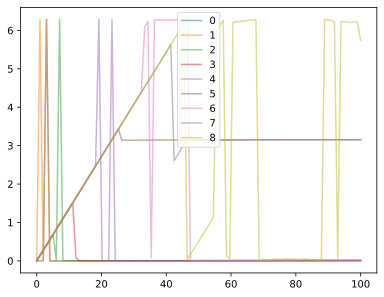

In [66]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
for i in range(9):
    resid = (np.array(phase1[i]) - np.array(omega*new_tlist))%(2*np.pi)
    plt.plot(new_tlist,resid,label=f"{i}",alpha=0.5)
# plt.ylim(0,0.1)
plt.legend(loc = 'upper center')